# Ejercicio 01  MLP Keras: Iris

Copia de trabajo. Se conserva la corrida original `4 x 3 x 3`, se agregan exactamente dos capas ocultas para `4 x 3 x 3 x 3 x 3` y se incluye el reto opcional.

## Paso 1  Preparacion y datos

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

SEED = 123
ETA = 0.03
EPOCHS = 500
np.random.seed(SEED)
tf.random.set_seed(SEED)

iris = datasets.load_iris()
X = iris.data.astype(float)
y = iris.target
Y = to_categorical(y).astype(float)
print("X:", X.shape, "Y:", Y.shape)


X: (150, 4) Y: (150, 3)


## Paso 2  Corrida original `4 x 3 x 3`

La red tiene una capa oculta de tres neuronas y una salida de tres neuronas. Usamos sigmoide, MSE, SGD con `learning_rate=0.03` y 500 epocas.

Model: "iris_original"

 Layer (type)                     Output Shape                  Param # 

 layer1 (Dense)                   (None, 3)                          15 

 layer2 (Dense)                   (None, 3)                          12

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

error inicial: 0.303676 | error final: 0.221660 | accuracy: 0.3333 | tiempo: 28.388 s


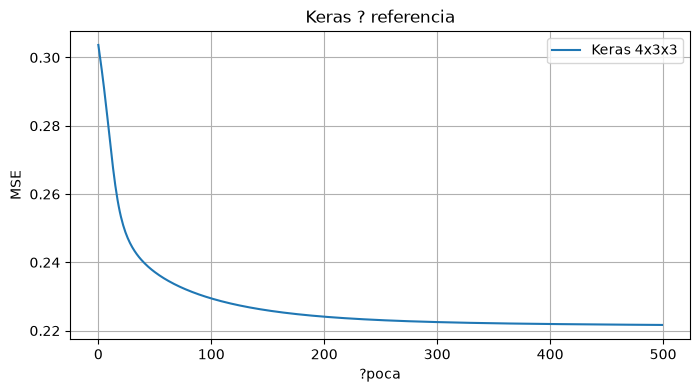

Prediccion de ejemplo [3, 3, 1, 1]: [[0.35134196 0.33977392 0.33686605]]


In [2]:
model_original = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer1"),
    layers.Dense(3, activation="sigmoid", name="layer2"),
], name="iris_original")
model_original.summary()
model_original.compile(optimizer=keras.optimizers.SGD(learning_rate=ETA), loss=keras.losses.MeanSquaredError())
started = time.perf_counter()
history_original = model_original.fit(X, Y, epochs=EPOCHS, verbose=0)
time_original = time.perf_counter() - started
pred_original = model_original.predict(X, verbose=0)
acc_original = np.mean(pred_original.argmax(axis=1) == y)
print(f"error inicial: {history_original.history['loss'][0]:.6f} | error final: {history_original.history['loss'][-1]:.6f} | accuracy: {acc_original:.4f} | tiempo: {time_original:.3f} s")
plt.figure(figsize=(8, 4)); plt.plot(history_original.history['loss'], label="Keras 4x3x3"); plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Keras  referencia"); plt.legend(); plt.grid(True); plt.show()
print("Prediccion de ejemplo [3, 3, 1, 1]:", model_original.predict(np.array([[3, 3, 1, 1]]), verbose=0))


## Paso 3  Corrida profunda `4 x 3 x 3 x 3 x 3`

Se agregan dos `Dense(3)` antes de la salida. `model.summary()` debe mostrar cuatro capas Dense en total.

Model: "iris_deep"

 Layer (type)                     Output Shape                  Param # 

 layer1 (Dense)                   (None, 3)                          15 

 layer2 (Dense)                   (None, 3)                          12 

 layer3 (Dense)                   (None, 3)                          12 

 layer4 (Dense)                   (None, 3)                          12

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

error inicial: 0.237125 | error final: 0.222132 | accuracy: 0.3333 | tiempo: 25.357 s


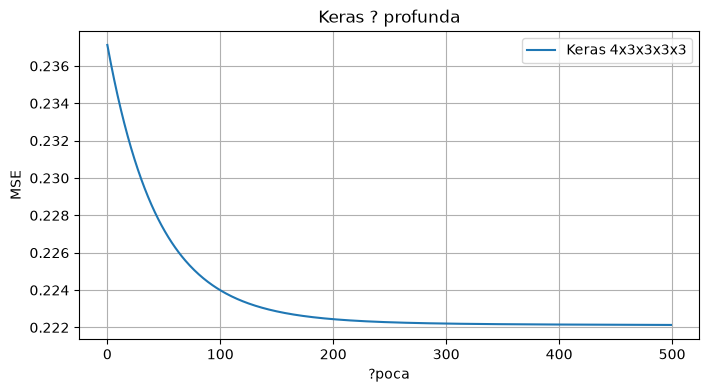

Prediccion de ejemplo [3, 3, 1, 1]: [[0.34232518 0.33018944 0.32725394]]


In [3]:
model_deep = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer1"),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
], name="iris_deep")
model_deep.summary()
model_deep.compile(optimizer=keras.optimizers.SGD(learning_rate=ETA), loss=keras.losses.MeanSquaredError())
started = time.perf_counter()
history_deep = model_deep.fit(X, Y, epochs=EPOCHS, verbose=0)
time_deep = time.perf_counter() - started
pred_deep = model_deep.predict(X, verbose=0)
acc_deep = np.mean(pred_deep.argmax(axis=1) == y)
print(f"error inicial: {history_deep.history['loss'][0]:.6f} | error final: {history_deep.history['loss'][-1]:.6f} | accuracy: {acc_deep:.4f} | tiempo: {time_deep:.3f} s")
plt.figure(figsize=(8, 4)); plt.plot(history_deep.history['loss'], label="Keras 4x3x3x3x3"); plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Keras  profunda"); plt.legend(); plt.grid(True); plt.show()
print("Prediccion de ejemplo [3, 3, 1, 1]:", model_deep.predict(np.array([[3, 3, 1, 1]]), verbose=0))


## Paso 4  Comparacion Keras

La grafica conjunta y la tabla son la evidencia numrica de la comparacion.

{'keras_original_final_error': 0.22166021168231964, 'keras_deep_final_error': 0.22213220596313477, 'keras_original_accuracy': 0.3333333333333333, 'keras_deep_accuracy': 0.3333333333333333, 'keras_original_time': 28.387603599985596, 'keras_deep_time': 25.35743399997591}


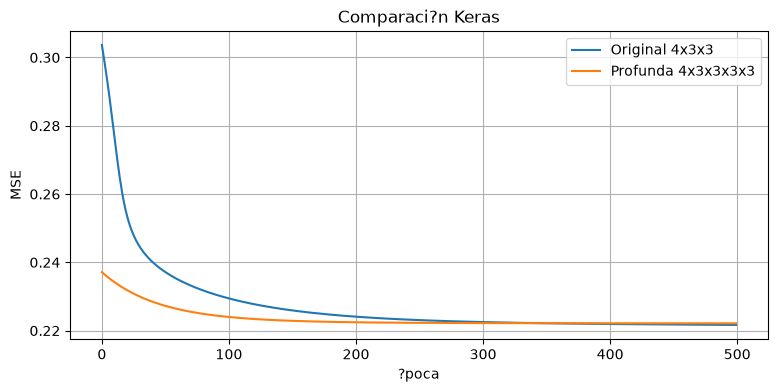

In [4]:
keras_results = {
    "keras_original_final_error": float(history_original.history['loss'][-1]),
    "keras_deep_final_error": float(history_deep.history['loss'][-1]),
    "keras_original_accuracy": float(acc_original),
    "keras_deep_accuracy": float(acc_deep),
    "keras_original_time": float(time_original),
    "keras_deep_time": float(time_deep),
}
print(keras_results)
plt.figure(figsize=(9, 4)); plt.plot(history_original.history['loss'], label="Original 4x3x3"); plt.plot(history_deep.history['loss'], label="Profunda 4x3x3x3x3"); plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Comparacion Keras"); plt.legend(); plt.grid(True); plt.show()


## Reto opcional A  ReLU + softmax + categorical crossentropy

Aqui si cambia la funcion de activacion y la perdida, porque es precisamente lo que pide el reto. La salida softmax representa probabilidades que suman 1.

Reto ReLU/softmax | perdida final: 0.184039 | accuracy final: 0.9533
Evaluacion [loss, accuracy]: [0.2586538791656494, 0.9066666960716248]


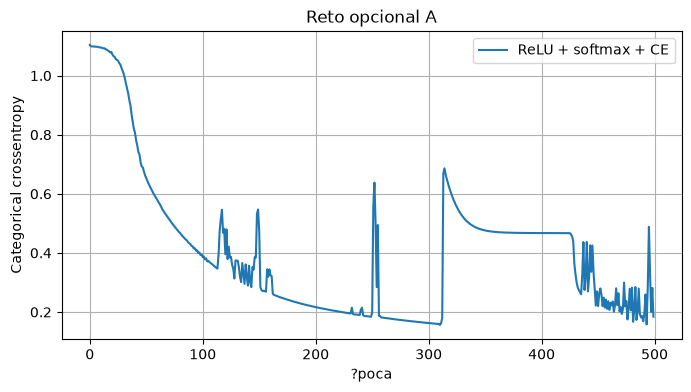

In [5]:
model_relu = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(3, activation="relu", name="hidden1"),
    layers.Dense(3, activation="relu", name="hidden2"),
    layers.Dense(3, activation="relu", name="hidden3"),
    layers.Dense(3, activation="softmax", name="output"),
], name="iris_relu_softmax")
model_relu.compile(optimizer=keras.optimizers.SGD(learning_rate=ETA), loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])
history_relu = model_relu.fit(X, Y, epochs=EPOCHS, verbose=0)
relu_eval = model_relu.evaluate(X, Y, verbose=0)
print(f"Reto ReLU/softmax | perdida final: {history_relu.history['loss'][-1]:.6f} | accuracy final: {history_relu.history['accuracy'][-1]:.4f}")
print("Evaluacion [loss, accuracy]:", relu_eval)
plt.figure(figsize=(8, 4)); plt.plot(history_relu.history['loss'], label="ReLU + softmax + CE"); plt.xlabel("epoca"); plt.ylabel("Categorical crossentropy"); plt.title("Reto opcional A"); plt.legend(); plt.grid(True); plt.show()


## Reto opcional B  Capas ocultas de 8 neuronas

In [6]:
model_wide = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="sigmoid", name="hidden1"),
    layers.Dense(8, activation="sigmoid", name="hidden2"),
    layers.Dense(8, activation="sigmoid", name="hidden3"),
    layers.Dense(3, activation="sigmoid", name="output"),
], name="iris_wide")
model_wide.compile(optimizer=keras.optimizers.SGD(learning_rate=ETA), loss=keras.losses.MeanSquaredError())
history_wide = model_wide.fit(X, Y, epochs=EPOCHS, verbose=0)
pred_wide = model_wide.predict(X, verbose=0)
acc_wide = np.mean(pred_wide.argmax(axis=1) == y)
print(f"Reto 8x8x8 | perdida final: {history_wide.history['loss'][-1]:.6f} | accuracy: {acc_wide:.4f}")


Reto 8x8x8 | perdida final: 0.222050 | accuracy: 0.3333


## Evidencia y reporte

Captura los dos `model.summary()`, las cuatro curvas principales y la salida de prediccion. Los numeros impresos se usaran en el reporte final.
